<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ?
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv
population = pd.read_csv('/content/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('/content/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('/content/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('/content/sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
print("Le nombre est de {} colonne(s) ".format(population.shape[1]))
#La nature des données dans chacune des colonnes
print(population.info())
#Le nombre de valeurs présentes dans chacune des colonnes
print(population.count())

Le nombre est de 3 colonne(s) 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB
None
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [5]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur'] = population['Valeur']*1000

In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur' : 'Population'}, inplace=True)
population['Population'] = population['Population'].astype(int)

In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589
1,Afghanistan,2014,33370794
2,Afghanistan,2015,34413603
3,Afghanistan,2016,35383032
4,Afghanistan,2017,36296113


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [9]:
#Afficher les dimensions du dataset
print(dispo_alimentaire.shape)

(15605, 18)


In [10]:
#Consulter le nombre de colonnes
print(f"Nombre de colonnes :{dispo_alimentaire.shape[1]}")

Nombre de colonnes :18


In [11]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [12]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)

In [13]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
col_T_en_KG =[
              'Aliments pour animaux',
              'Autres Utilisations',
              'Disponibilité intérieure',
              'Exportations - Quantité',
              'Importations - Quantité',
              'Nourriture',
              'Pertes',
              'Production',
              'Semences',
              'Traitement',
              'Variation de stock'
              ]
dispo_alimentaire[col_T_en_KG] = (dispo_alimentaire[col_T_en_KG]*1000000).round().astype(int)

In [14]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0,0,5.0,1.72,0.20,0.77,53000000,0,0,53000000,0,53000000,0,0,0
1,Afghanistan,"Agrumes, Autres",vegetale,0,0,1.0,1.29,0.01,0.02,41000000,2000000,40000000,39000000,2000000,3000000,0,0,0
2,Afghanistan,Aliments pour enfants,vegetale,0,0,1.0,0.06,0.01,0.03,2000000,0,2000000,2000000,0,0,0,0,0
3,Afghanistan,Ananas,vegetale,0,0,0.0,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0
4,Afghanistan,Bananes,vegetale,0,0,4.0,2.70,0.02,0.05,82000000,0,82000000,82000000,0,0,0,0,0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [15]:
#Afficher les dimensions du dataset
print(aide_alimentaire.shape)

(1475, 4)


In [16]:
#Consulter le nombre de colonnes
print(f"Le nombre de colonnes est : {aide_alimentaire.shape[1]}")

Le nombre de colonnes est : 4


In [17]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [18]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire' : 'Zone'}, inplace=True)

In [19]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur'] = (aide_alimentaire['Valeur']*1000).astype(int)

In [20]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [21]:
#Afficher les dimensions du dataset
print(sous_nutrition.shape)

(1218, 3)


In [22]:
#Consulter le nombre de colonnes
print(f"Le nombre de colonnes est : {sous_nutrition.shape[1]}")

Le nombre de colonnes est : 3


In [23]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [24]:
#Conversion de la colonne sous nutrition en numérique
   ### sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

In [25]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')
sous_nutrition.fillna(0, inplace=True)

In [26]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={'Valeur' : 'sous_nutrition'}, inplace=True)

In [27]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition'] = (sous_nutrition['sous_nutrition']*1000000).astype(int)

In [28]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000
1,Afghanistan,2013-2015,8800000
2,Afghanistan,2014-2016,8900000
3,Afghanistan,2015-2017,9700000
4,Afghanistan,2016-2018,10500000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [29]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
# Jointure entre les tables population et sous_nutrition
sous_nutrition_2017 = pd.merge(population, sous_nutrition, on='Zone', how='left')

# Filtrer les années 2017 et '2016-2018'
population_sous_nutrition = sous_nutrition_2017[(sous_nutrition_2017['Année_x'] == 2017) & ((sous_nutrition_2017['Année_y'] == '2016-2018') | (sous_nutrition_2017['Année_y'] == 2017))]

# Convertir la colonne 'sous_nutrition' en entier
population_sous_nutrition.loc[:, 'sous_nutrition'] = population_sous_nutrition['sous_nutrition'].astype(int)

# Ajouter une nouvelle colonne 'Année' avec les années filtrées
population_sous_nutrition.loc[:, 'Année'] = 2017

#Supprimer les colonnes Année_x et Année_y
population_sous_nutrition = population_sous_nutrition.drop(columns=['Année_x', 'Année_y'])

<ipython-input-29-154d2ef1a267>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  population_sous_nutrition.loc[:, 'Année'] = 2017


In [30]:
#Affichage du dataset
population_sous_nutrition

,Zone,Population,sous_nutrition,Année
28,Afghanistan,36296113,10500000.0,2017
64,Afrique du Sud,57009756,3100000.0,2017
100,Albanie,2884169,100000.0,2017
136,Algérie,41389189,1300000.0,2017
172,Allemagne,82658409,0.0,2017
...,...,...,...,...
7354,Venezuela (République bolivarienne du),29402484,8000000.0,2017
7390,Viet Nam,94600648,6500000.0,2017
7426,Yémen,27834819,0.0,2017
7462,Zambie,16853599,0.0,2017


A présent nous allons calculer la population mondiale en 2017 pour ensuite calculer le ratio de personnes en sous nutrition par rapport à la population mondiale

In [31]:
# Calcul population mondiale 2017
popu_mondiale_2017 = population_sous_nutrition[population_sous_nutrition['Année'] == 2017]['Population'].sum()
print(popu_mondiale_2017)

7543798769


In [32]:
# Calcul et affichage du nombre de personnes en état de sous nutrition
per_sous_nutrition_2017 = population_sous_nutrition['sous_nutrition'].sum()
print('Le nombre de personnes en état de sous-nutrition : ', per_sous_nutrition_2017)

Le nombre de personnes en état de sous-nutrition :  535700000.0


In [33]:
# Ratio de la population mondiale en sous_nutrition 2017
taux_pop_sous_nutri = per_sous_nutrition_2017 / popu_mondiale_2017 * 100
taux_2017 = round(taux_pop_sous_nutri,2)
taux_2017
print('Le pourcentage de sous nutrition est de', taux_2017, '%')

Le pourcentage de sous nutrition est de 7.1 %


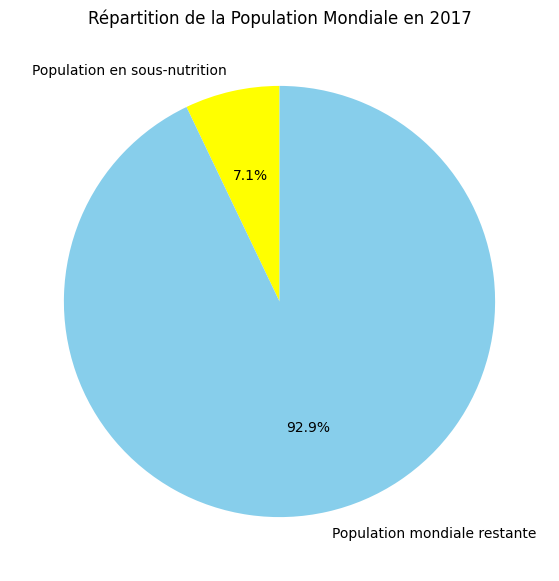

In [34]:
# Définir les valeurs pour le pie chart
sous_nutri_2017 = taux_2017.sum()
reste_pop_mondiale = 100 - sous_nutri_2017

# Créer une liste des valeurs
data = [sous_nutri_2017, reste_pop_mondiale]

# Créer des labels pour les sections du pie chart
labels = ['Population en sous-nutrition', 'Population mondiale restante']

# Définir des couleurs pour les sections
colors = ['Yellow', 'Skyblue']

# Création du diagramme circulaire
plt.figure(figsize=(10, 7))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Répartition de la Population Mondiale en 2017')
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

L'apport calorique théorique dont un être humain à besoin **2250** kcals en moyenne.
Ce chiffre s'appuie sur les données du VIDAL, spécialiste français de la santé.

https://www.vidal.fr/sante/nutrition/equilibre-alimentaire-adulte/recommandations-nutritionnelles-adulte.html

In [35]:
# Combien mange en moyenne un être humain ?
# On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
dispo_alim_zone_origine_2017 = dispo_alimentaire.groupby(['Zone', 'Origine']).sum().reset_index()

In [36]:
# Focus sur population de l'année 2017
pop_ss_nutri_2017 = population_sous_nutrition.loc[population_sous_nutrition['Année'] == 2017, :]

In [37]:
# Agrégation des données pour 2017
dispo_pop_2017 = pd.merge(dispo_alim_zone_origine_2017, pop_ss_nutri_2017[['Zone', 'Population', 'sous_nutrition']],  on='Zone', how='left')

In [38]:
#Affichage du nouveau dataframe
dispo_pop_2017.head()

,Zone,Origine,Produit,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,sous_nutrition
0,Afghanistan,animale,"Abats ComestibleBeurre, GheeCrèmeGraisses Anim...",123000000,0,216.0,79.92,15.23,12.21,2631000000,0,350000000,2442000000,63000000,2280000000,2000000,0,0,36296113.0,10500000.0
1,Afghanistan,vegetale,"Agrumes, AutresAliments pour enfantsAnanasBana...",645000000,415000000,1871.0,271.49,18.27,46.05,10884000000,278000000,2638000000,8293000000,1072000000,8891000000,393000000,63000000,-368000000,36296113.0,10500000.0
2,Afrique du Sud,animale,Abats ComestibleAnimaux Aquatiques AutreBeurre...,187000000,115000000,487.0,139.63,34.66,36.39,7817000000,1088000000,1049000000,7371000000,83000000,7614000000,67000000,0,241000000,57009756.0,3100000.0
3,Afrique du Sud,vegetale,"Agrumes, AutresAlcool, non ComestibleAliments ...",5122000000,761000000,2533.0,425.17,48.92,48.94,53439000000,10586000000,6468000000,22441000000,2110000000,55649000000,186000000,22819000000,1912000000,57009756.0,3100000.0
4,Albanie,animale,Abats ComestibleAnimaux Aquatiques AutreBeurre...,101000000,2000000,985.0,389.05,67.72,59.41,1432000000,10000000,87000000,1235000000,94000000,1355000000,0,0,0,2884169.0,100000.0


In [39]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
dispo_pop_2017['Dispo kcal totale'] = (dispo_pop_2017['Population']*dispo_pop_2017['Disponibilité alimentaire (Kcal/personne/jour)']).round(2)

In [40]:
#Calcul de la disponibilité calories mondialement
dispo_kcal_mondiale = dispo_pop_2017['Dispo kcal totale'].sum().astype(int)

# Variable consommation moyenne en kcal d'un être humain
kcal_moyenne = 2250

# Calcul du nombre d'humains pouvant être nourris
humains_nourris = (dispo_kcal_mondiale/kcal_moyenne).astype(int)

# Calcul du pourcentage d'être humain pouvant être nourris sur la population mondiale
prctg_humains_nourris = round((humains_nourris/popu_mondiale_2017)*100,1)
print("Le pourcentage d'être humain pouvant être nourris est de",prctg_humains_nourris,'%')

# Conversion en milliards
humains_nourris_mlds = humains_nourris / 1e9
popu_mondiale_mlds = popu_mondiale_2017 / 1e9

Le pourcentage d'être humain pouvant être nourris est de 123.2 %


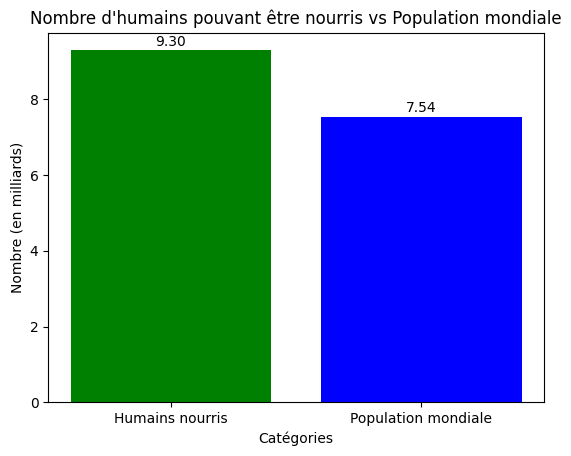

In [100]:
# Données pour les barres
categories = ['Humains nourris', 'Population mondiale']
values = [humains_nourris_mlds, popu_mondiale_mlds]

# Création du diagramme à barres
plt.bar(categories, values, color=['green', 'blue'])

# Titre et labels
plt.title("Nombre d'humains pouvant être nourris vs Population mondiale")
plt.xlabel("Catégories")
plt.ylabel("Nombre (en milliards)")

# Afficher les valeurs sur chaque barre
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

# Afficher le graphique
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [42]:
# Transfert des données avec les végétaux dans un nouveau dataframe
produits_vgt = dispo_pop_2017[dispo_pop_2017['Origine'] =='vegetale']

In [102]:
# Calcul du nombre de kcal disponible pour les végétaux
dispo_kcal_mondiale_vgt = dispo_pop_2017.loc[dispo_pop_2017['Origine'] =='vegetale', 'Dispo kcal totale'].sum().astype(int)
print(dispo_kcal_mondiale_vgt)
# Pourcentage des kcals d'origine végétales
tx_vegt = round((dispo_kcal_mondiale_vgt /dispo_kcal_mondiale)*100,1)

# Pourcentage des kcals d'origine animale
tx_animal = round(100 - tx_vegt, 1)

17260764197424


In [101]:
# Calcul du nombre d'humains pouvant être nourris avec les végétaux
humains_nourris_vgt = round(dispo_kcal_mondiale_vgt / kcal_moyenne)
print("Le nombre d'humains pouvant être nourris pouvant être nourris avec les végétaux est de",humains_nourris_vgt,'personnes.')

# ratio d'humains pouvant être nourris avec des végétaux
ratio_humains_nourris_vgt = round((humains_nourris_vgt / popu_mondiale_2017)*100,1)
print("La proportion d'humains pouvant être nourris avec des végétaux",ratio_humains_nourris_vgt,'%')

# Conversion en milliards
humains_nourris_vgt_bar = humains_nourris_vgt / 1e9
popu_mondiale_mlds = popu_mondiale_2017 / 1e9

Le nombre d'humains pouvant être nourris pouvant être nourris avec les végétaux est de 7671450754 personnes.
La proportion d'humains pouvant être nourris avec des végétaux 101.7 %


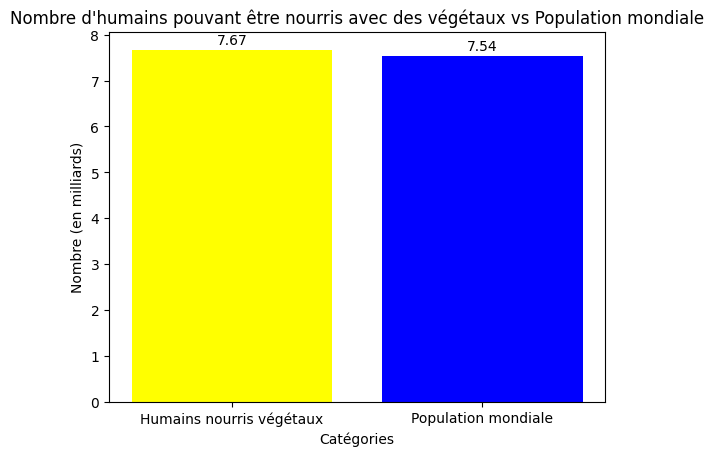

In [103]:
# Données pour les barres
categories = ['Humains nourris végétaux', 'Population mondiale']
values = [humains_nourris_vgt_bar, popu_mondiale_mlds]

# Création du diagramme à barres
plt.bar(categories, values, color=['yellow', 'blue'])

# Titre et labels
plt.title("Nombre d'humains pouvant être nourris avec des végétaux vs Population mondiale")
plt.xlabel("Catégories")
plt.ylabel("Nombre (en milliards)")

# Afficher les valeurs sur chaque barre
for i, value in enumerate(values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

# Afficher le graphique
plt.show()

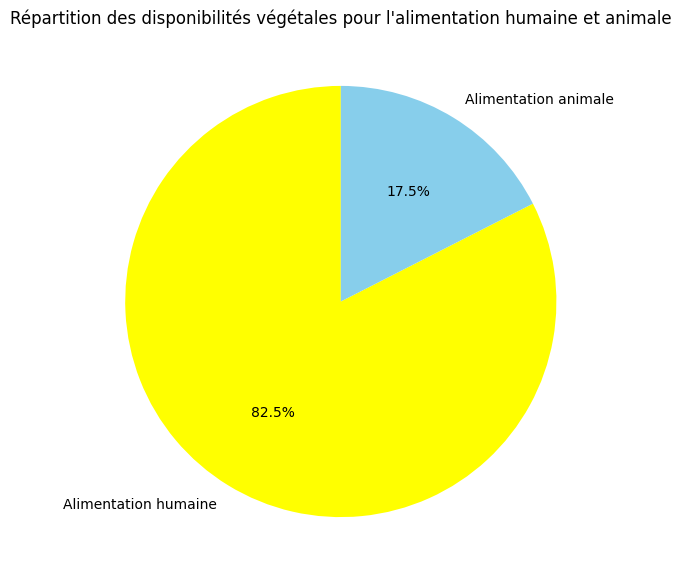

Le pourcentage dédié à l'alimentation humaine est de: 82.5%.
Le pourcentage dédié à l'alimentation animale est de: 17.5%.


In [104]:
# Données pour le diagramme circulaire
labels = ['Alimentation humaine', 'Alimentation animale']
sizes = [tx_vegt, tx_animal]

# Création du diagramme circulaire
plt.figure(figsize=(10, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['Yellow','Skyblue'])
plt.title("Répartition des disponibilités végétales pour l'alimentation humaine et animale")
plt.show()

# Affichage des résultats
print(f'Le pourcentage dédié à l\'alimentation humaine est de: {tx_vegt}%.')
print(f'Le pourcentage dédié à l\'alimentation animale est de: {tx_animal}%.')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [46]:
# Liste de l'équation pour la disponibilité intérieure
liste_dispo_int = ['Aliments pour animaux', 'Autres Utilisations', 'Nourriture', 'Pertes', 'Semences', 'Traitement']

# Création du df pour le bar chart
data_dispo_int = dispo_alimentaire[liste_dispo_int]

# Calcul de la somme de chaque colonne
total_data_dispo_int = data_dispo_int.sum(axis=0)

# Calcul du total de la disponiblité
total_dispo = total_data_dispo_int.sum()
print("\nLa somme totale de toutes les lignes est :",total_dispo)

# Tri des données en ordre décroissant
total_data_dispo_int_sorted = total_data_dispo_int.sort_values(ascending=False)


La somme totale de toutes les lignes est : 9858592000000


In [47]:
# Comparaison Equation valeur côté A
Equa_cote_A = ['Importations - Quantité', 'Exportations - Quantité', 'Production', 'Variation de stock']

# Calcul du total pour chauqe ligne en respectant l'équation
dispo_alimentaire['TOTAL'] = dispo_alimentaire['Production'] + dispo_alimentaire['Importations - Quantité'] - dispo_alimentaire['Exportations - Quantité'] + dispo_alimentaire['Variation de stock']

# Calcul de la somme totale de toutes les lignes
somme_Equa_cote_A = dispo_alimentaire['TOTAL'].sum()

print("\nLa somme totale de toutes les lignes est :", somme_Equa_cote_A)


La somme totale de toutes les lignes est : 9849173000000


- 9858592000000
- 9849173000000

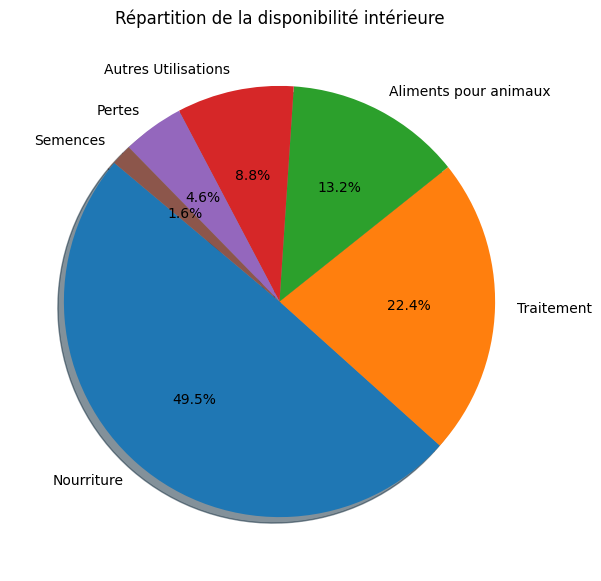

In [48]:
# Création du diagramme circulaire
plt.figure(figsize=(10, 7))
plt.pie(total_data_dispo_int_sorted, labels=total_data_dispo_int_sorted.index, autopct='%1.1f%%', startangle=140, shadow=True)
plt.title("Répartition de la disponibilité intérieure")
plt.show()

In [49]:
# Création d'un dictionnaire pour stocker les sommes
somme_dispo_int = {}

# # Création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, etc...
for value in liste_dispo_int:
    somme_value = round(dispo_alimentaire[value].sum())
    somme_dispo_int[value] = somme_value

# Tri du dictionnaire par ordre décroissant des valeurs
somme_dispo_int_sorted = dict(sorted(somme_dispo_int.items(), key=lambda item: item[1], reverse=True))

# Affichage des résultats triés
for key, value in somme_dispo_int_sorted.items():
    print(f"La disponibilité pour la catégorie {key} correspond à {value} kg.")


La disponibilité pour la catégorie Nourriture correspond à 4876258000000 kg.
La disponibilité pour la catégorie Traitement correspond à 2204687000000 kg.
La disponibilité pour la catégorie Aliments pour animaux correspond à 1304245000000 kg.
La disponibilité pour la catégorie Autres Utilisations correspond à 865023000000 kg.
La disponibilité pour la catégorie Pertes correspond à 453698000000 kg.
La disponibilité pour la catégorie Semences correspond à 154681000000 kg.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [50]:
#Création d'une liste avec toutes les variables
liste_cereales = ['Blé', 'Céréales, Autres', 'Maïs', 'Millet', 'Orge', 'Riz (Eq Blanchi)', 'Avoine', 'Seigle', 'Sorgho']

In [51]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
cereale_df = dispo_alimentaire[dispo_alimentaire['Produit'].isin(liste_cereales)]
cereale_df.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,TOTAL
7,Afghanistan,Blé,vegetale,0,0,1369.0,160.23,4.69,36.91,5992000000,0,1173000000,4895000000,775000000,5169000000,322000000,0,-350000000,5992000000
12,Afghanistan,"Céréales, Autres",vegetale,0,0,0.0,0.00,0.00,0.00,0,0,0,0,0,0,0,0,0,0
32,Afghanistan,Maïs,vegetale,200000000,0,21.0,2.50,0.30,0.56,313000000,0,1000000,76000000,31000000,312000000,5000000,0,0,313000000
34,Afghanistan,Millet,vegetale,0,0,3.0,0.40,0.02,0.08,13000000,0,0,12000000,1000000,13000000,0,0,0,13000000
40,Afghanistan,Orge,vegetale,360000000,0,26.0,2.92,0.24,0.79,524000000,0,10000000,89000000,52000000,514000000,22000000,0,0,524000000


In [52]:
# Création bdd céréales
bdd_dispo_int_cereale = cereale_df[liste_dispo_int]

# Calcul de la somme de chaque colonne
total_bdd_dispo_int_cereale = bdd_dispo_int_cereale.sum(axis=0)

# Calcul du total
total_dispo_cereale = total_bdd_dispo_int_cereale.sum()

# Tri des données en ordre décroissant
total_bdd_dispo_int_cereale_sorted = total_bdd_dispo_int_cereale.sort_values(ascending=False)

In [53]:
# Répartition de chaque céréale par utilisation
repart_cereale = cereale_df.groupby('Produit')[liste_dispo_int].sum()

# Calcul du total de chaque ligne
totals_par_produit = repart_cereale.sum(axis=1)

# Transformation en pourcentage
pourcentages_cereales = (repart_cereale.div(totals_par_produit, axis=0) * 100).round(1).sort_values(by='Nourriture', ascending=False)

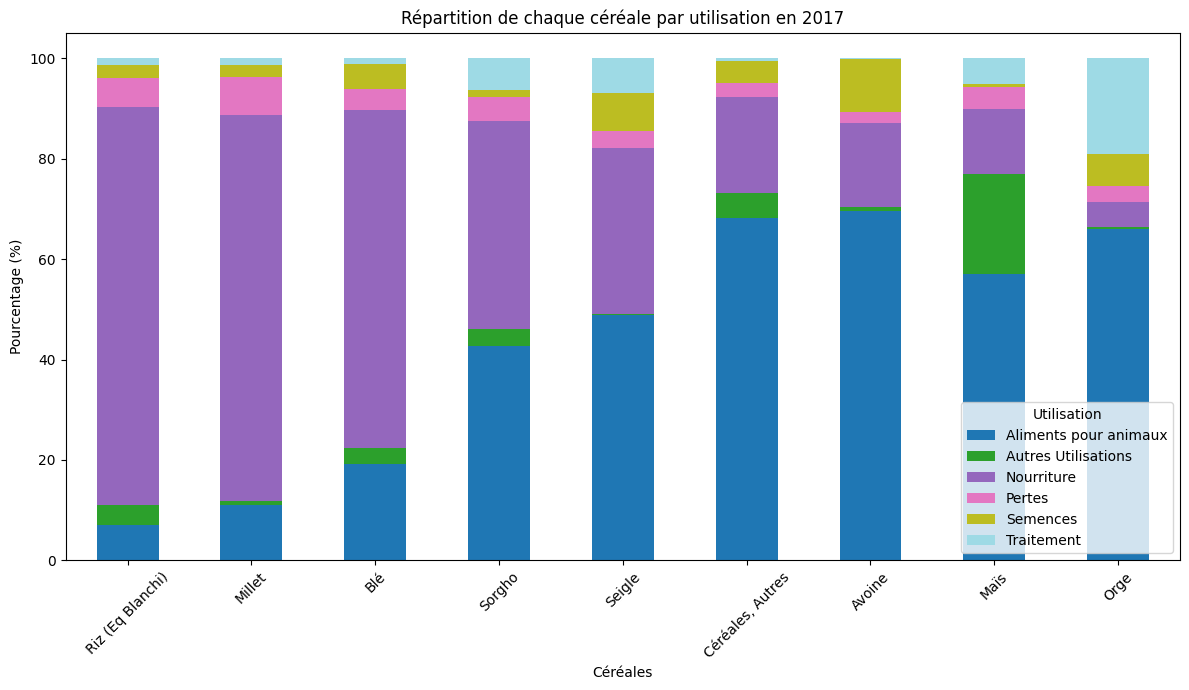

In [54]:
# Création du diagramme en barres empilées
ax = pourcentages_cereales.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

# Personnalisation du graphique
plt.xlabel('Céréales')
plt.ylabel('Pourcentage (%)')
plt.title('Répartition de chaque céréale par utilisation en 2017')
plt.legend(title='Utilisation')
plt.xticks(rotation=45)
plt.tight_layout()

# Affichage du graphique
plt.show()

In [55]:
#Affichage de la proportion d'alimentation animale

In [56]:
# Calculer la somme de la colonne "Aliments pour animaux"
somme_aliments_pour_animaux = cereale_df['Aliments pour animaux'].sum()

In [57]:
somme_aliments_pour_animaux
prctg_aliments_pr_animaux = round((somme_aliments_pour_animaux/total_dispo_cereale)*100,2)

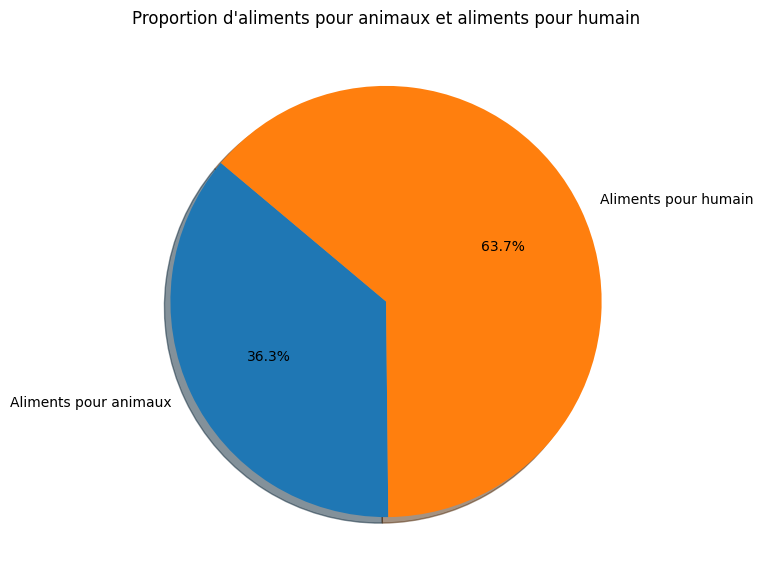

In [58]:

# Valeurs pour le diagramme circulaire
reste_dispo_cereale = 100 - prctg_aliments_pr_animaux
values = [prctg_aliments_pr_animaux, reste_dispo_cereale]
labels = ['Aliments pour animaux', 'Aliments pour humain']

# Création du diagramme circulaire
plt.figure(figsize=(10, 7))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, shadow=True)
plt.title("Proportion d'aliments pour animaux et aliments pour humain")
plt.show()

DIAGRAMME CIRCULAIRE

Sous nutrition ===> comprendre, analyser, causalité, problème d'utilisation cf. diagramme circulaire, nourriture sous exploitée, aide-alimentaire dimunition, Yémen contexte, pays dispo -/+ <2250 kcals / Thailande utilisation assez de manioc 80 % du manioc est exportée .

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [59]:
#Création de la colonne proportion par pays
population_sous_nutrition['proportion par pays'] = ((population_sous_nutrition['sous_nutrition']/population_sous_nutrition['Population'])*100).round(2)

In [60]:
#création df des 10 pays avec la proportion de personnes sous-alimentée la plus forte
df_top_10_sous_nutri = population_sous_nutrition.loc[population_sous_nutrition['Année'] == 2017].sort_values(by='proportion par pays', ascending=False).head(10)

#calcul du nombre total de personnes dans les 10 pays
total_top_10_sous_nutri = df_top_10_sous_nutri['sous_nutrition'].sum()

#calcul du taux des 10 pays par rapport à la population mondiale en état de sous-nutrition
taux_top_10_sous_nutri = (total_top_10_sous_nutri/sous_nutri_2017)*100

#affichage après trie des 10 pays avec la proportion de personnes sous-alimentée la plus forte


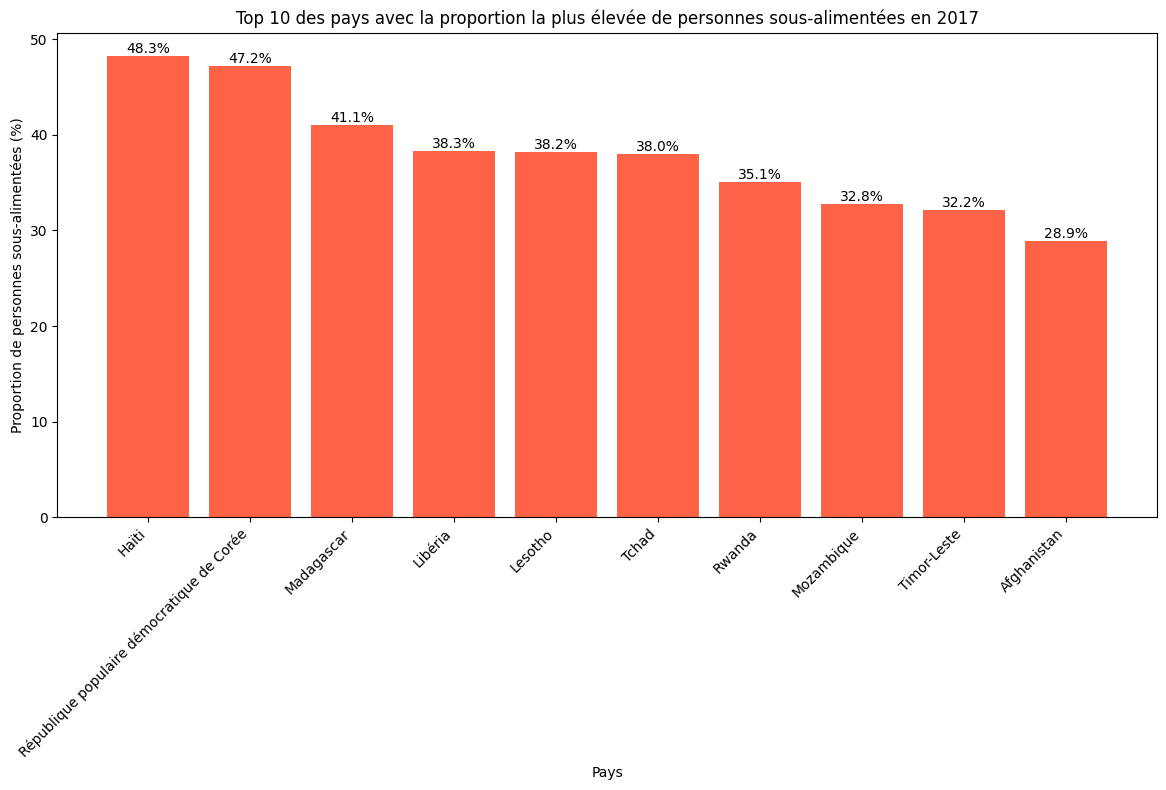

In [61]:
# Définir la couleur rouge pour les barres
bar_color = '#FF6347'  # Tomato Red

# Création du diagramme à barres
plt.figure(figsize=(12, 8))
bars = plt.bar(df_top_10_sous_nutri['Zone'], df_top_10_sous_nutri['proportion par pays'], color=bar_color)
plt.xlabel('Pays')
plt.ylabel('Proportion de personnes sous-alimentées (%)')
plt.title('Top 10 des pays avec la proportion la plus élevée de personnes sous-alimentées en 2017')
plt.xticks(rotation=45, ha='right')

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [62]:
#calcul du total de l'aide alimentaire par pays
total_aide = aide_alimentaire.groupby('Zone')['Valeur'].sum()

# Top 10 des pays
top_10_aide_pays = total_aide.sort_values(ascending=False).head(10).round(0)

# Calcul de la proportion de ces 10 pays par rapport à l'aide mondiale
pourcentage_top_10_pays_aide = (top_10_aide_pays.sum()/total_aide.sum())*100

In [63]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire

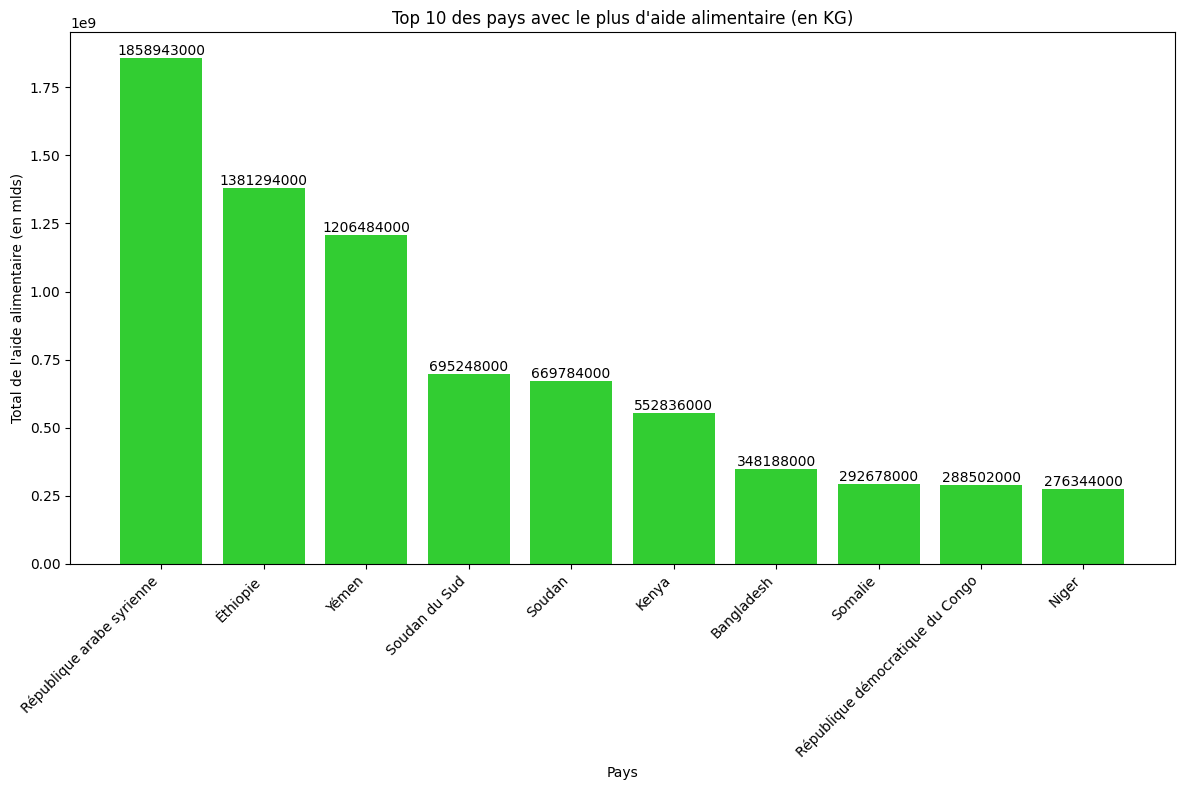

In [64]:
# Définir la couleur verte pour les barres
bar_color = '#32CD32'  # Lime Green

# Création du diagramme à barres
plt.figure(figsize=(12, 8))
bars = plt.bar(top_10_aide_pays.index, top_10_aide_pays.values, color= bar_color)
plt.xlabel('Pays')
plt.ylabel('Total de l\'aide alimentaire (en mlds)')
plt.title('Top 10 des pays avec le plus d\'aide alimentaire (en KG)')
plt.xticks(rotation=45, ha='right')

# Ajouter les valeurs au-dessus des barres en nombre entier
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [65]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
evolution_aide = aide_alimentaire.drop(columns=['Produit']).groupby(['Zone', 'Année']).sum()

In [66]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
liste_top5_pays = ['République arabe syrienne','Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [67]:
#On filtre sur le dataframe avec notre liste
evolution_aide_top5_pays = evolution_aide.loc[evolution_aide.index.get_level_values('Zone').isin(liste_top5_pays)].reset_index()

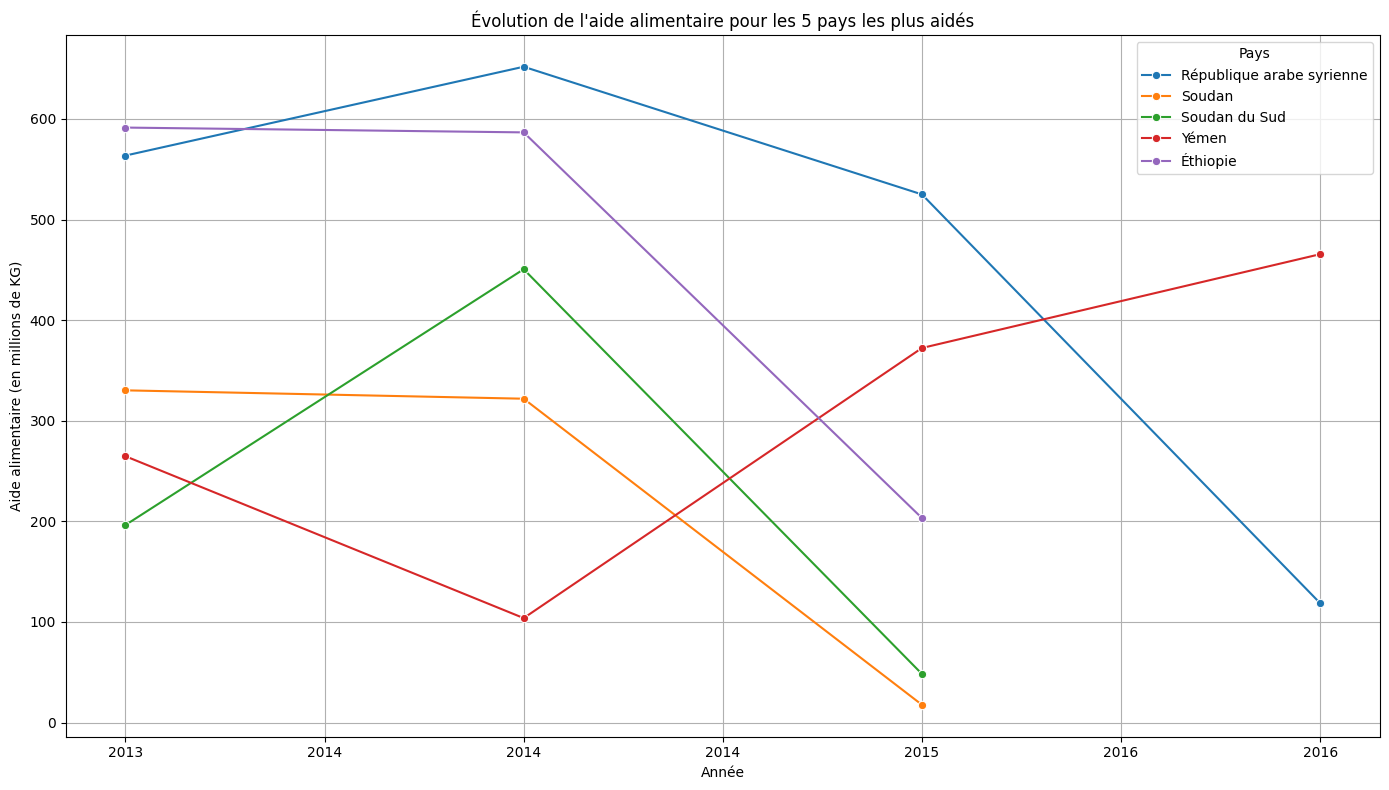

In [68]:
# On filtre sur le dataframe avec notre liste
evolution_aide_top5_pays = evolution_aide.loc[evolution_aide.index.get_level_values('Zone').isin(liste_top5_pays)].reset_index()

# Grouper par année et zone pour éviter les doublons
evolution_aide_top5_pays = evolution_aide_top5_pays.groupby(['Année', 'Zone']).sum().reset_index()

# Création de la courbe de tendance
plt.figure(figsize=(14, 8))
sns.lineplot(data=evolution_aide_top5_pays, x='Année', y='Valeur', hue='Zone', marker='o')

# Ajout des labels et titre
plt.xlabel('Année')
plt.ylabel('Aide alimentaire (en millions de KG)')
plt.title('Évolution de l\'aide alimentaire pour les 5 pays les plus aidés')
plt.legend(title='Pays')
plt.grid(True)

# Formatage de l'axe x pour enlever .0
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))

# Formatage de l'axe y pour afficher en millions sans les zéros inutiles
def millions(x, pos):
    'The two args are the value and tick position'
    return f'{x*1e-6:.0f}'

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(millions))

# Ajustement de la mise en page
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [69]:
#Calcul de la disponibilité en kcal par personne par jour par pays
kcal_par_pers_2017 = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].agg('sum')

In [70]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
top10_pays_moins_dispo_2017 = kcal_par_pers_2017.sort_values(ascending=True).head(10)

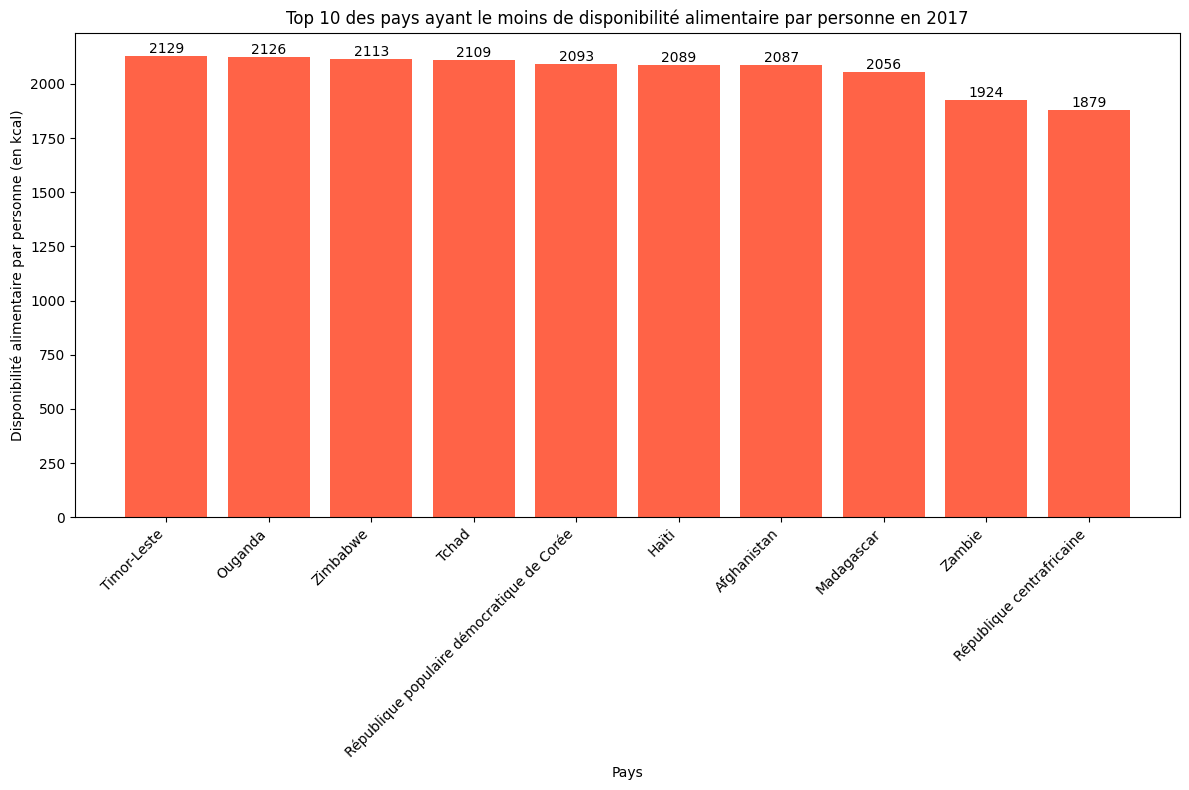

In [71]:
# Inverser l'ordre pour avoir les plus grandes valeurs à gauche
top10_pays_moins_dispo_2017 = top10_pays_moins_dispo_2017[::-1]

# Création du diagramme à barres verticales
plt.figure(figsize=(12, 8))
bars = plt.bar(top10_pays_moins_dispo_2017.index, top10_pays_moins_dispo_2017.values, color='#FF6347')
plt.xlabel('Pays')
plt.ylabel('Disponibilité alimentaire par personne (en kcal)')
plt.title('Top 10 des pays ayant le moins de disponibilité alimentaire par personne en 2017')

# Ajouter les valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [72]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
top10_pays_plus_dispo_2017 = kcal_par_pers_2017.sort_values(ascending=False).head(10)

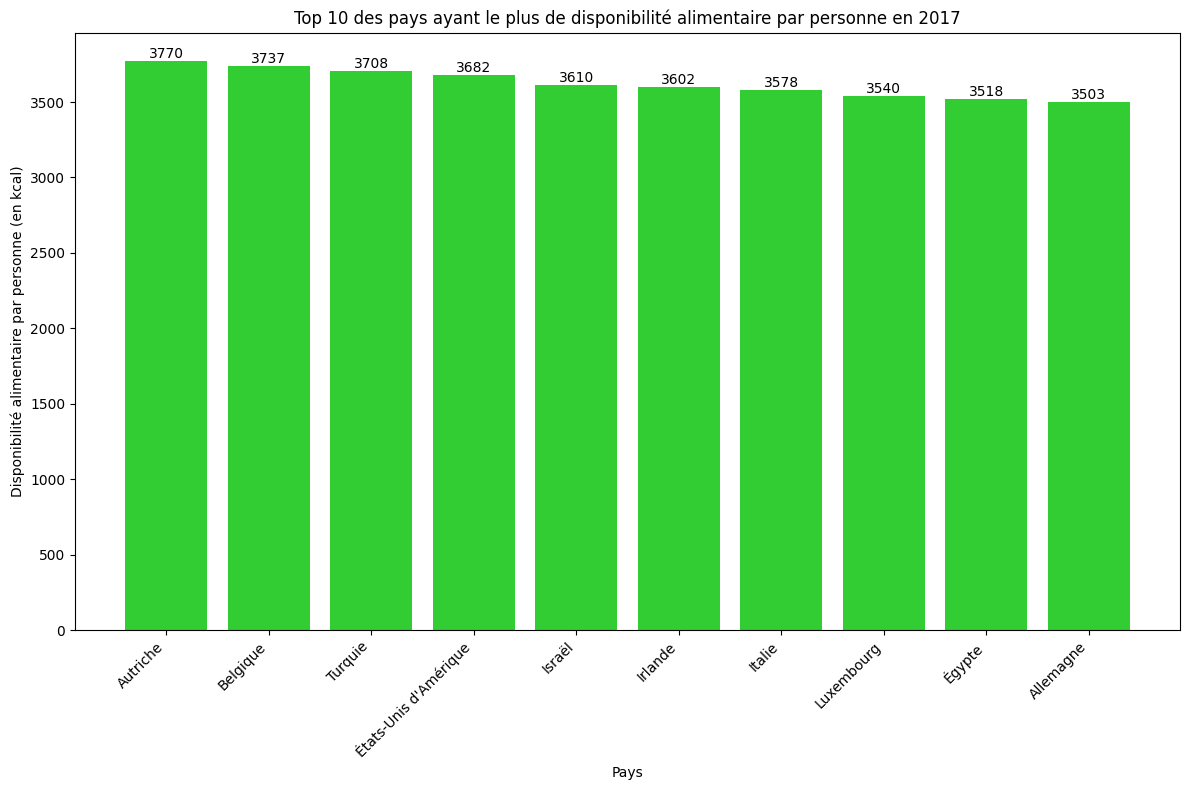

In [73]:
# Création du diagramme à barres verticales
plt.figure(figsize=(12, 8))
bars = plt.bar(top10_pays_plus_dispo_2017.index, top10_pays_plus_dispo_2017.values, color='#32CD32')  # Lime Green pour indicateur positif
plt.xlabel('Pays')
plt.ylabel('Disponibilité alimentaire par personne (en kcal)')
plt.title('Top 10 des pays ayant le plus de disponibilité alimentaire par personne en 2017')

# Ajouter les valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [74]:
#création d'un dataframe avec uniquement la Thaïlande
dispo_thailande = dispo_alimentaire[dispo_alimentaire['Zone'] == 'Thaïlande']
dispo_thailande.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,TOTAL
13759,Thaïlande,Abats Comestible,animale,0,0,3.0,1.11,0.09,0.56,74000000,5000000,33000000,75000000,0,45000000,0,0,0,73000000
13760,Thaïlande,"Agrumes, Autres",vegetale,0,0,0.0,0.09,0.00,0.00,8000000,6000000,2000000,6000000,0,12000000,0,2000000,0,8000000
13761,Thaïlande,"Alcool, non Comestible",vegetale,0,358000000,0.0,0.00,0.00,0.00,358000000,110000000,21000000,0,0,447000000,0,0,0,358000000
13762,Thaïlande,Aliments pour enfants,vegetale,0,0,2.0,0.18,0.01,0.08,12000000,7000000,19000000,12000000,0,0,0,0,0,12000000
13763,Thaïlande,Ananas,vegetale,0,0,10.0,10.02,0.04,0.08,782000000,1449000000,9000000,671000000,110000000,2209000000,0,0,13000000,782000000


In [75]:
#Calcul de la sous nutrition en Thaïlande
## manioc_thailande = dispo_pays[['Thailande']['Produit'] == ['Manioc']]
# Filtrer les données pour obtenir le manioc en Thaïlande
manioc_thailande = dispo_thailande[(dispo_thailande['Produit'] == 'Manioc')]
manioc_thailande

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,TOTAL
13809,Thaïlande,Manioc,vegetale,1800000000,2081000000,40.0,13.0,0.05,0.14,6264000000,25214000000,1250000000,871000000,1511000000,30228000000,0,0,0,6264000000


In [76]:
# Fonction permettant d'afficher la population, le nombre de personne en sous-nutrition et la proportion de ce nombre en 2017
def table_popu_sous_nutri_pays(pays) :
  table_popu_sous_nutri_pays = population_sous_nutrition.loc[population_sous_nutrition['Zone'] == pays]
  return table_popu_sous_nutri_pays

In [77]:
table_popu_sous_nutri_pays('Thaïlande')

,Zone,Population,sous_nutrition,Année,proportion par pays
6886,Thaïlande,69209810,6200000.0,2017,8.96


In [78]:
# On calcule la proportion exportée en fonction de la production
export_manioc = round((manioc_thailande['Exportations - Quantité'] / manioc_thailande['Production']) * 100, 2)
nourriture_manioc = round((manioc_thailande['Nourriture'] / manioc_thailande['Production']) * 100, 2)

print(f"Bien que 9% de la population Thaïlandaise soit en sous-nutrition entre 2013 et 2017, le pays exporte plus de {export_manioc.values[0]}% de sa production de manioc en 2017 et ne consacre que {nourriture_manioc.values[0]}% à l'alimentation humaine !")

Bien que 9% de la population Thaïlandaise soit en sous-nutrition entre 2013 et 2017, le pays exporte plus de 83.41% de sa production de manioc en 2017 et ne consacre que 2.88% à l'alimentation humaine !


In [79]:
# Fonction permettant d'afficher la dispo kcal par personne selon le pays choisi
def kcl_pr_pers(pays):
  kcl_pr_pers = kcal_par_pers_2017.loc[kcal_par_pers_2017.index== pays]
  kcl_pr_pers_pays = kcl_pr_pers.reset_index()
  return kcl_pr_pers_pays

In [80]:
# Quelle est la disponibilité par habitant pour la Thaïlande ?
display(kcl_pr_pers('Thaïlande'))
print('Il y a 2785 kcals par personne en Thaïlande en 2017, ce qui place ce pays au dessus des recommandations de la FAO (2200 kcals).')

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Thaïlande,2785.0


Il y a 2785 kcals par personne en Thaïlande en 2017, ce qui place ce pays au dessus des recommandations de la FAO (2200 kcals).


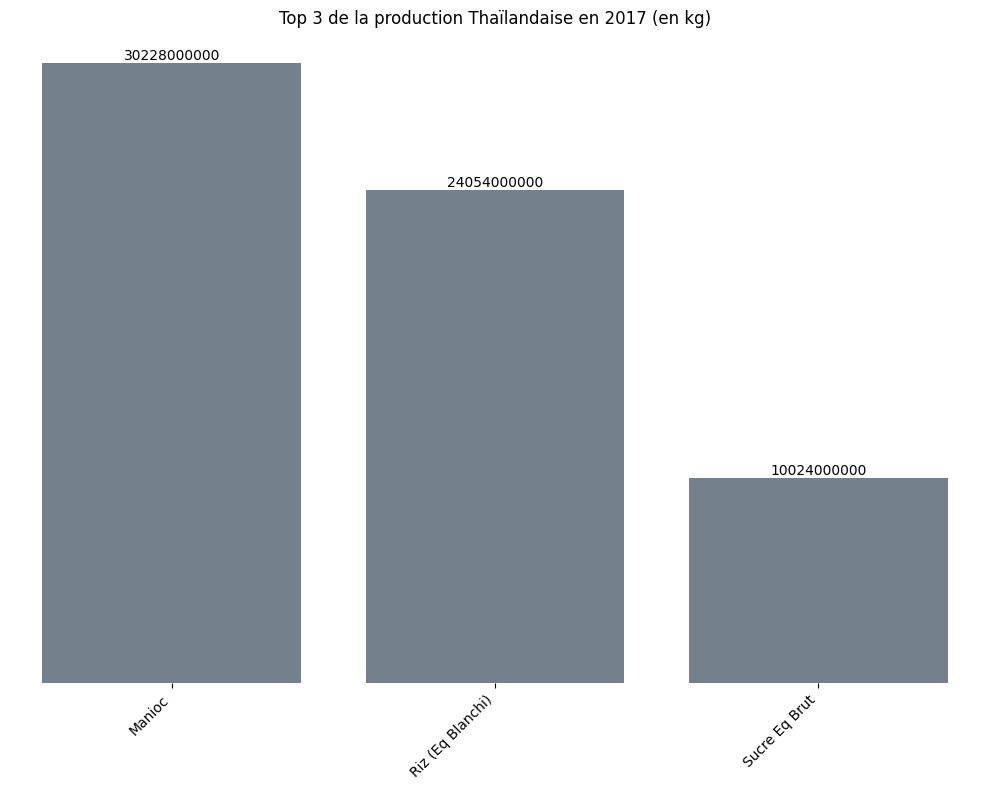

Le Manioc est la denrée la plus produite par la Thaïlande.


In [81]:
# Top 3 produits de la Thaïlande
df_prdc_thailande = (dispo_alimentaire[dispo_alimentaire['Zone'] == 'Thaïlande']
                .groupby('Produit')
                .sum()
                .sort_values(by='Exportations - Quantité', ascending=False)
                .head(3)
               )

# Création du graphique en barres avec Seaborn
plt.figure(figsize=(10, 8))
sns.barplot(x='Produit', y='Production', data=df_prdc_thailande, color='slategrey')

# Ajout des valeurs au-dessus des barres
for index, value in enumerate(df_prdc_thailande['Production']):
    plt.text(index, value, round(value), ha='center', va='bottom')

# Ajour des titres
plt.xlabel('')
plt.title('Top 3 de la production Thaïlandaise en 2017 (en kg)')

# Supression de l'axe des y et sa ligne
plt.gca().axes.get_yaxis().set_visible(False)
sns.despine(left=True, bottom=True)

# Ajustement des étiquettes de l'axe x
plt.xticks(rotation=45, ha='right')

# Amélioration de la lisibilité du graphique
plt.tight_layout()

plt.show()

print("Le Manioc est la denrée la plus produite par la Thaïlande.")

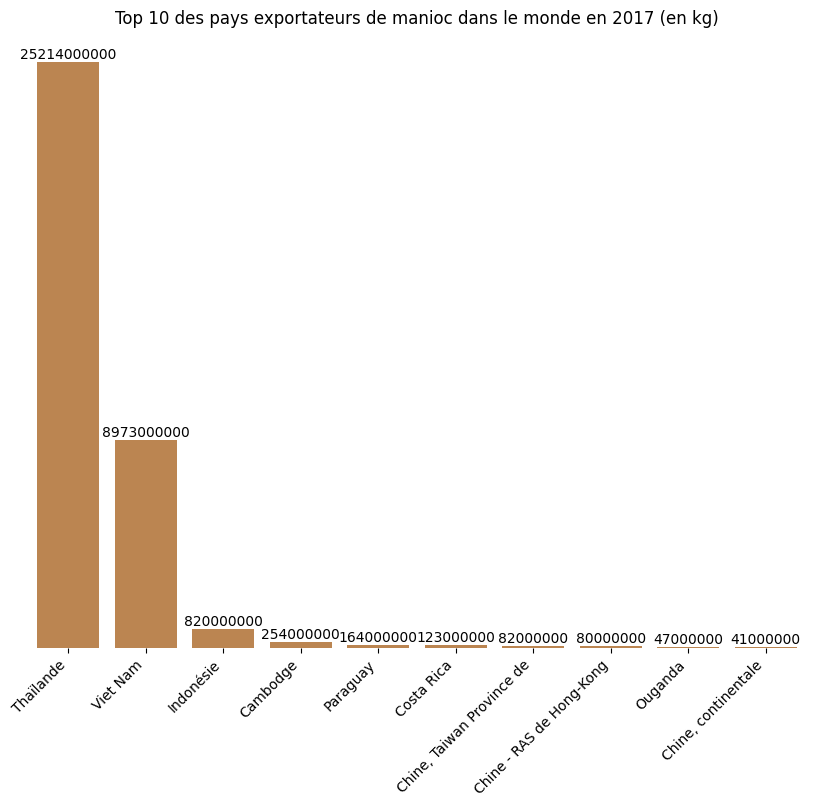

In [82]:
# Top 10 des pays exportateur de manioc
df_expor_manioc = (dispo_alimentaire[dispo_alimentaire['Produit'] == 'Manioc']
                   .sort_values(by='Exportations - Quantité', ascending=False)
)

#Variable pour n'avoir que les 10 premiers pays exportateur de manioc
top_10_expor_manioc = df_expor_manioc.head(10)

# Création du graphique en barres avec Seaborn
plt.figure(figsize=(10, 8))
sns.barplot(x='Zone', y='Exportations - Quantité', data=top_10_expor_manioc, color='peru')

# Ajout des valeurs au-dessus des barres
for index, value in enumerate(top_10_expor_manioc['Exportations - Quantité']):
    plt.text(index, value, round(value), ha='center', va='bottom')

# Ajout des titres
plt.xlabel('')
plt.title('Top 10 des pays exportateurs de manioc dans le monde en 2017 (en kg)')

# Supression de l'axe des y et sa ligne
plt.gca().axes.get_yaxis().set_visible(False)
sns.despine(left=True, bottom=True)

# Ajustement des étiquettes de l'axe x
plt.xticks(rotation=45, ha='right')

plt.show()

In [83]:
# Calcul de la production totale de manioc
production_manioc_total = manioc_thailande['Production'].sum()

# Calcul de l'exportation totale de manioc
export_manioc_total = df_expor_manioc['Exportations - Quantité'].sum()


production_manioc_thailande = 30228000000


export_manioc_thailande = 25214000000

# Calcul de la proportion de la production thaïlandaise de manioc par rapport au reste du monde
prpr_production_manioc_thailande = round((production_manioc_thailande/production_manioc_total)*100, 2)

# Calcul de la proportion de l'exportation thaïlandaise de manioc par rapport au reste du monde
prpr_export_manioc_thailande = round((export_manioc_thailande/export_manioc_total)*100, 2)

print(f"La Thaïlande est le 1er exportateur de manioc dans le monde, le pays exporte 25 millions de tonnes de manioc, soit {prpr_export_manioc_thailande}% de l'exportation mondiale.")

La Thaïlande est le 1er exportateur de manioc dans le monde, le pays exporte 25 millions de tonnes de manioc, soit 69.94% de l'exportation mondiale.


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [84]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être
#le plus en difficulté au niveau alimentaire"

In [85]:
# Création d'un df regroupant l'aide alimentaire par pays
pourcentage_aide = aide_alimentaire.groupby('Zone').sum()
pourcentage_aide.drop('Année', axis=1, inplace=True)

# Calcul du total de chaque ligne
total_aide_2013_2016 = pourcentage_aide['Valeur'].sum()

# Ajout de la colonne répartition pour identifier la part de l'aide alimentaire par pays
pourcentage_aide['repartition_aide'] = (pourcentage_aide['Valeur']/total_aide_2013_2016)*100

#Reset_index pour filtrer plus facilement sur le pays
pourcentage_aide.reset_index(drop=False, inplace=True)

display(table_popu_sous_nutri_pays('Haïti'))
display(pourcentage_aide.loc[pourcentage_aide['Zone']=="Haïti"])

print("Bien qu'étant le pays avec la plus grande proportion de personnes en sous-nutrition entre 2013 et 2017, Haïti ne représente que 1% des aides alimentaires entre 2013 et 2016 !")

,Zone,Population,sous_nutrition,Année,proportion par pays
2890,Haïti,10982366,5300000.0,2017,48.26


,Zone,Produit,Valeur,repartition_aide
25,Haïti,Autres non-céréalesAutres non-céréalesAutres n...,116450000,1.055193


Bien qu'étant le pays avec la plus grande proportion de personnes en sous-nutrition entre 2013 et 2017, Haïti ne représente que 1% des aides alimentaires entre 2013 et 2016 !
